In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
df = pd.read_csv('Telco_customer_churn.csv')

In [62]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [63]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [64]:
df.shape

(7043, 33)

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [66]:
quality_summary = pd.DataFrame({
    'missing_values': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'dtype': df.dtypes.astype(str)
}).sort_values('missing_values', ascending=False)

quality_summary.head(10)

,missing_values,missing_pct,dtype
Churn Reason,5174,73.46,str
CustomerID,0,0.00,str
Count,0,0.00,int64
State,0,0.00,str
Country,0,0.00,str
Zip Code,0,0.00,int64
Lat Long,0,0.00,str
Latitude,0,0.00,float64
City,0,0.00,str
Gender,0,0.00,str


In [67]:
duplicate_rows = df.duplicated().sum()
duplicate_rows

np.int64(0)

In [68]:
eda_df = df.copy()

In [69]:
eda_df['Churn_Num'] = eda_df['Churn Label'].map({'Yes' : 1, 'No' : 0})

The target variable is `Churn Label`. The dataset is imbalanced: around 26.54% of customers churned and 73.46% did not churn.

Text(0.5, 1.0, 'Churn Rate')

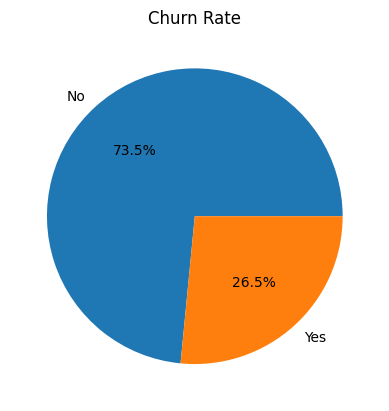

In [70]:
eda_df['Churn Label'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Churn Rate')

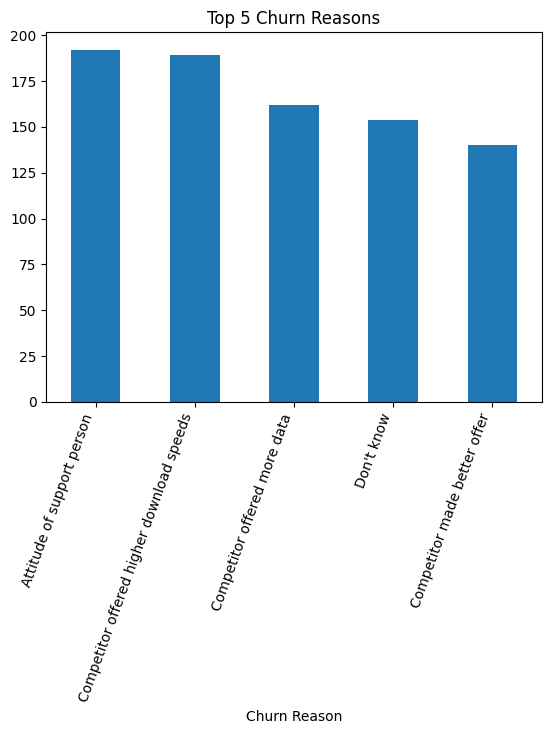

In [71]:
top_5_churn_reasons = eda_df['Churn Reason'].value_counts().head()
top_5_churn_reasons.plot(kind='bar')
plt.xticks(rotation=70, ha='right')
plt.title('Top 5 Churn Reasons')
plt.show()

The top churn reasons are concentrated around support experience and competitor offers, so retention actions should focus on both service quality and competitive value.

## Key Churn Drivers

This section checks the main behavioral and commercial factors linked with churn: contract type, tenure, monthly charges, payment method, and support/security services.

<Axes: >

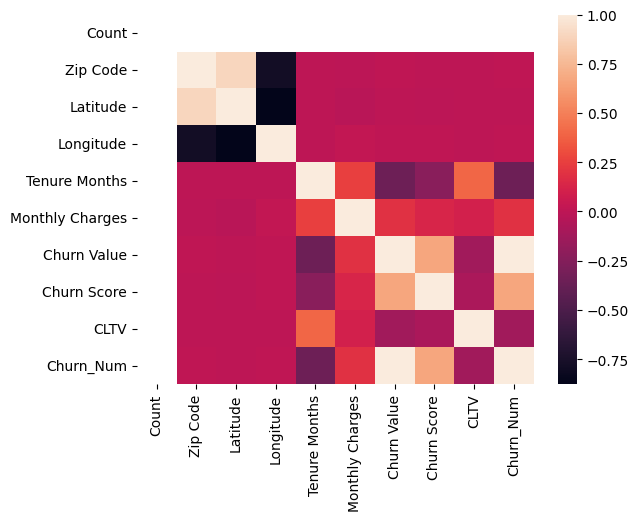

In [72]:
sns.heatmap(eda_df.corr(numeric_only=True))

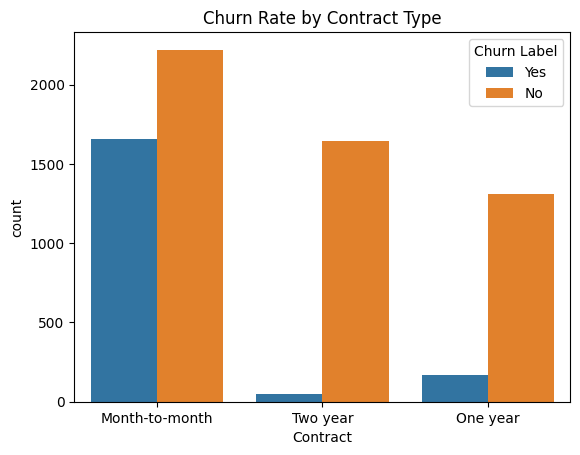

In [73]:
sns.countplot(x='Contract',hue='Churn Label',data=eda_df)
plt.title('Churn Rate by Contract Type')
plt.show()

In [74]:
pd.crosstab(eda_df['Contract'], eda_df['Churn Label'], normalize='index') * 100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


**Contract insight:** Month-to-month customers have the highest churn rate at about 42.71%, compared with 11.27% for one-year contracts and 2.83% for two-year contracts.

In [75]:
eda_df['Tenure Months'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Tenure Months, dtype: float64

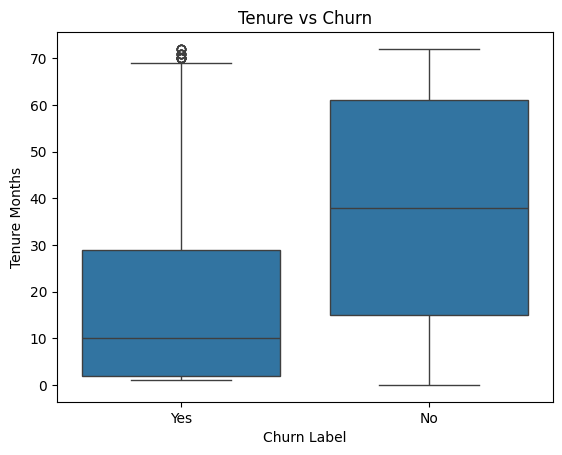

In [76]:

sns.boxplot(x='Churn Label', y='Tenure Months', data=eda_df)
plt.title("Tenure vs Churn")
plt.show()

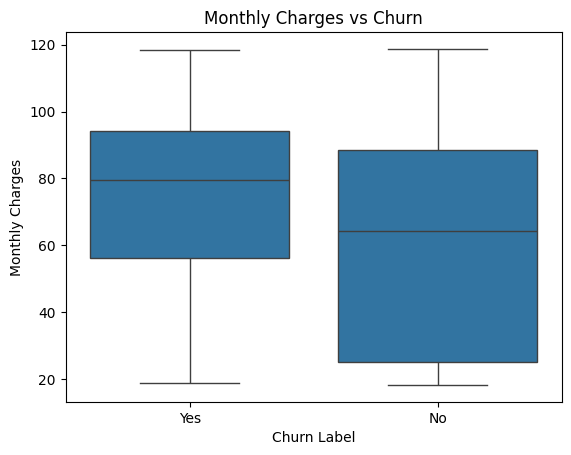

In [77]:
# eda_df['Monthly Charges'].describe()
sns.boxplot(x='Churn Label', y='Monthly Charges', data=eda_df)
plt.title("Monthly Charges vs Churn")
plt.show()

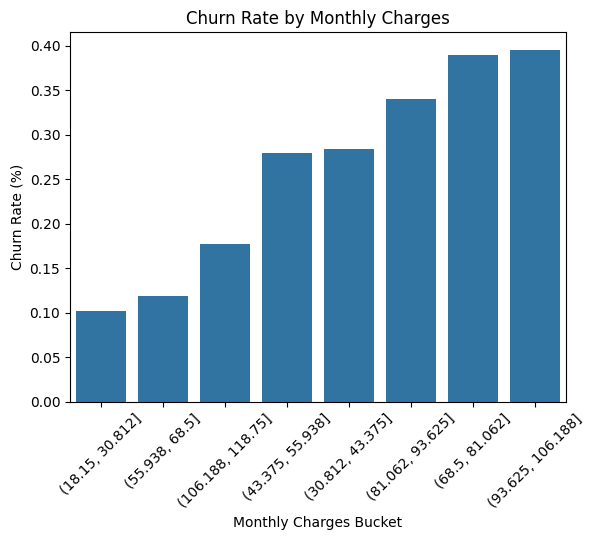

In [78]:
eda_df['charge_bucket'] = pd.cut(eda_df['Monthly Charges'], bins=8)

bucket_churn = (
    eda_df.groupby('charge_bucket')['Churn_Num']
    .mean()
    .reset_index(name='churn_rate')
    .sort_values('churn_rate')
)

sns.barplot(
    x='charge_bucket',
    y='churn_rate',
    data=bucket_churn,
    order=bucket_churn['charge_bucket']
)

plt.xticks(rotation=45)
plt.ylabel("Churn Rate (%)")
plt.xlabel("Monthly Charges Bucket")
plt.title("Churn Rate by Monthly Charges")
plt.show()

In [79]:
eda_df.groupby(['Tech Support','Online Security'])['Churn_Num'].mean()

Tech Support         Online Security    
No                   No                     0.489620
                     Yes                    0.213043
No internet service  No internet service    0.074050
Yes                  No                     0.223280
                     Yes                    0.090082
Name: Churn_Num, dtype: float64

In [80]:
churn_by_payment_method = eda_df.groupby('Payment Method')['Churn_Num'].mean().sort_values(ascending=False).reset_index()
churn_by_payment_method

,Payment Method,Churn_Num
0,Electronic check,0.452854
1,Mailed check,0.191067
2,Bank transfer (automatic),0.167098
3,Credit card (automatic),0.152431


Churners tend to have lower tenure and higher monthly charges. Electronic check customers show the highest churn rate at about 45.29%. Customers without both tech support and online security also churn at a much higher rate than protected customers.

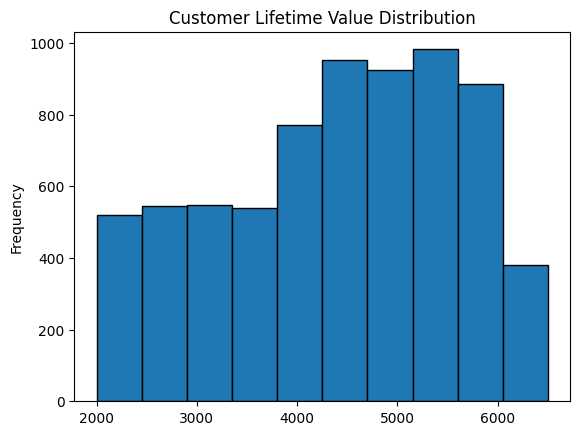

In [81]:
eda_df['CLTV'].plot(kind='hist',edgecolor='black')
plt.title('Customer Lifetime Value Distribution')
plt.show()

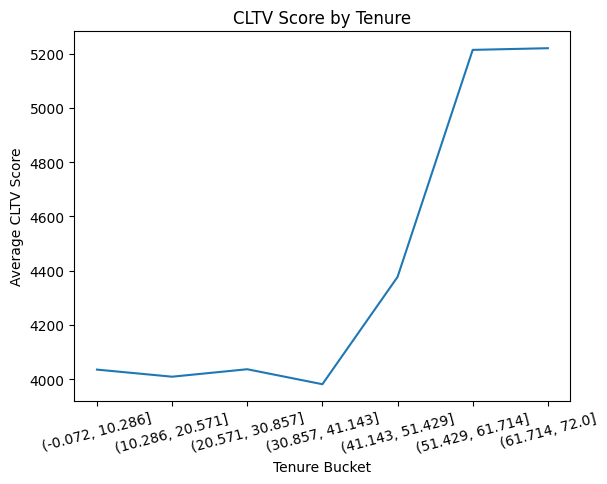

In [82]:
eda_df['tenure_bucket'] = pd.cut(eda_df['Tenure Months'], bins=7)

bucket_tenure = eda_df.groupby('tenure_bucket')['CLTV'].mean().reset_index(name='CLTV Score')

plt.plot(bucket_tenure['tenure_bucket'].astype(str),bucket_tenure['CLTV Score'])
plt.xticks(rotation=15)
plt.title("CLTV Score by Tenure")
plt.xlabel("Tenure Bucket")
plt.ylabel("Average CLTV Score")
plt.show()

Non-churned customers have higher average CLTV than churned customers, and CLTV generally improves with tenure. This makes early-life churn especially costly because customers leave before their full value develops.

## Loyalty Segmentation

A loyalty score is created using scaled CLTV, contract commitment, and automatic payment behavior. Customers are then grouped into Low, Medium, and High loyalty segments.

In [83]:
servie_cols = ['Streaming Movies', 'Streaming TV', 'Online Security', 'Tech Support']

for col in servie_cols:
  eda_df[col] = eda_df[col].map({'Yes' : 1, 'No' : 0, 'No internet service' : 0})

eda_df['num_services'] = eda_df[servie_cols].sum(axis=1)

In [84]:
eda_df['tenure_bucket1'] = pd.cut(eda_df['Tenure Months'],bins=[0,12,36,72],labels=['Low','Medium','High'])

In [85]:
# Pivot table
loyalty_check = eda_df.pivot_table(
    index='tenure_bucket1',
    columns='num_services',
    values='Churn_Num',
    aggfunc='mean'
)

loyalty_check = loyalty_check*100
loyalty_check

num_services,0,1,2,3,4
tenure_bucket1,,,,,
Low,41.792295,54.512635,60.501567,39.175258,45.454545
Medium,15.236686,33.407080,32.532751,27.906977,20.000000
High,4.729730,15.405405,19.286658,12.590449,7.449210


In [86]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

eda_df['CLTV_scaled'] = scaler.fit_transform(eda_df[['CLTV']])

In [87]:
eda_df['loyalty_score'] = (
    0.8*eda_df['CLTV_scaled'] + 
    0.1*eda_df['Contract'].map({'Month-to-month':0,'One year':1,'Two year':1}) +
    0.1*eda_df['Payment Method'].isin(['Bank transfer (automatic)','Credit card (automatic)']).astype(int)
)

Higher CLTV contributes most to the score, while long-term contracts and automatic payments add smaller loyalty signals.

In [88]:
eda_df['loyalty_segment'] = pd.cut(eda_df['loyalty_score'], bins=[0,0.3,0.6,1], labels=['Low','Medium','High'])

In [89]:
loyal_bucket_churn = eda_df.groupby('loyalty_segment')['Churn_Num'].mean().reset_index(name='churn_rate')

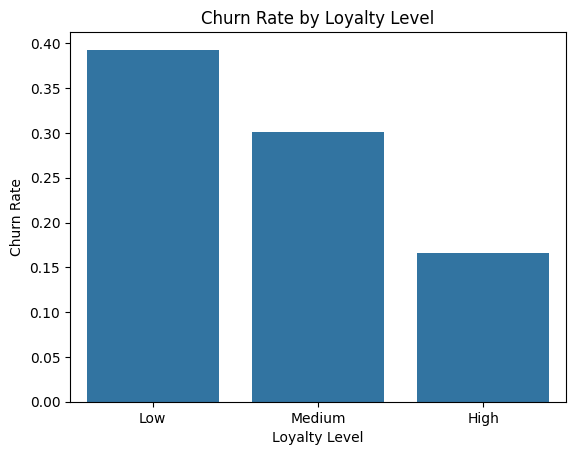

In [90]:
sns.barplot(x='loyalty_segment', y='churn_rate', data=loyal_bucket_churn, order=['Low','Medium','High'])
plt.ylabel("Churn Rate")
plt.xlabel("Loyalty Level")
plt.title("Churn Rate by Loyalty Level")
plt.show()

Churn decreases as loyalty score increases. The Low loyalty segment should be treated as the priority retention group.

## Insights

- Contract risk is the strongest visible pattern: month-to-month customers churn far more than one-year and two-year customers.
- Price pressure matters: churned customers have higher average monthly charges than retained customers.
- Early tenure is a danger zone: churned customers have much lower average tenure, so onboarding and first-year engagement are critical.
- Payment method is a useful risk signal: electronic check customers have the highest churn rate.
- Service protection reduces churn: customers with tech support and online security show much lower churn than customers without both.
- Competitor and support-related churn reasons suggest the business should improve support quality, communicate plan value clearly, and respond to competitor offers.

## Final Conclusions

The EDA shows that customer churn is driven mainly by weak commitment, short tenure, higher monthly charges, electronic check payments, and lack of support/security services. Month-to-month customers are the clearest high-risk group, while longer contracts, automatic payments, higher tenure, and stronger service bundles are linked with loyalty.

From a business perspective, the best retention focus is the Low loyalty segment, especially customers on month-to-month contracts with high monthly charges and limited support services. Recommended actions include improving onboarding, offering contract upgrade incentives, promoting automatic payments, bundling tech support or online security, and targeting competitor-sensitive customers with value-based offers.

Overall, the company should prioritize early retention and loyalty-building because customers who stay longer tend to generate higher CLTV and show much lower churn risk.

In [91]:
eda_df.columns.difference(df.columns)

Index(['CLTV_scaled', 'Churn_Num', 'charge_bucket', 'loyalty_score',
       'loyalty_segment', 'num_services', 'tenure_bucket', 'tenure_bucket1'],
      dtype='str')

# Feature Engineering for Model

In [ ]:
model_df = df.copy()

raw_model_df = df.copy()
raw_model_df['Total Charges'] = pd.to_numeric(raw_model_df['Total Charges'], errors='coerce')
raw_model_df = raw_model_df.dropna(subset=['Total Charges']).reset_index(drop=True)

In [93]:
services = ['Streaming Movies', 'Streaming TV', 'Online Security', 'Tech Support']
for col in services:
    model_df[col] = model_df[col].map({'Yes' : 1, 'No' : 0, 'No internet service' : 0})

model_df['num_services'] = model_df[services].sum(axis=1)

In [94]:
model_df['Total Charges'] = pd.to_numeric(model_df['Total Charges'], errors='coerce')
model_df.dropna(subset=['Total Charges'], inplace=True)

In [95]:
model_df['Avg monthly revenue'] = model_df['Total Charges'] / (model_df['Tenure Months'] + 1)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

cltv_scaler = MinMaxScaler()
model_df['CLTV_scaled'] = cltv_scaler.fit_transform(model_df[['CLTV']])

model_df['loyalty_score'] = round((
    0.8 * model_df['CLTV_scaled'] +
    0.1 * model_df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 1}) +
    0.1 * model_df['Payment Method'].isin(['Bank transfer (automatic)', 'Credit card (automatic)']).astype(int)
) * 100, 2)

In [97]:
useless_cols = model_df.iloc[:, :9].columns

model_df.drop(columns=useless_cols, inplace=True)
model_df.drop(columns=['Churn Label', 'Churn Reason'], inplace=True)
model_df.drop(columns=services, inplace=True)
model_df.drop(columns=['CLTV_scaled'], inplace=True)

In [98]:
col_to_fix = ['Multiple Lines', 'Online Backup', 'Device Protection']

for col in col_to_fix:
    model_df[col] = model_df[col].apply(lambda x: 1 if x == 'Yes' else 0)

In [99]:
model_df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Backup,Device Protection,...,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV,num_services,Avg monthly revenue,loyalty_score
0,Male,No,No,No,2,Yes,0,DSL,1,0,...,Yes,Mailed check,53.85,108.15,1,86,3239,1,36.050000,21.99
1,Female,No,No,Yes,2,Yes,0,Fiber optic,0,0,...,Yes,Electronic check,70.70,151.65,1,67,2701,0,50.550000,12.42
2,Female,No,No,Yes,8,Yes,1,Fiber optic,0,1,...,Yes,Electronic check,99.65,820.50,1,86,5372,2,91.166667,59.93
3,Female,No,Yes,Yes,28,Yes,1,Fiber optic,0,1,...,Yes,Electronic check,104.80,3046.05,1,84,5003,3,105.036207,53.37
4,Male,No,No,Yes,49,Yes,1,Fiber optic,1,1,...,Yes,Bank transfer (automatic),103.70,5036.30,1,89,5340,2,100.726000,69.36


## Encoding

In [100]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

transformer = ColumnTransformer(transformers=[
    ('tnf1', OrdinalEncoder(categories=[['No', 'Yes']] * 5), ['Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing']),
    ('tnf2', OneHotEncoder(sparse_output=False, drop='first'), ['Gender', 'Internet Service', 'Contract', 'Payment Method'])
], remainder='passthrough')

transformed_array = transformer.fit_transform(model_df)

In [101]:
transformed_cols = ['tnf1__Senior Citizen', 'tnf1__Partner', 'tnf1__Dependents',
       'tnf1__Phone Service', 'tnf1__Paperless Billing', 'tnf2__Gender_Male',
       'tnf2__Internet Service_Fiber optic', 'tnf2__Internet Service_No',
       'tnf2__Contract_One year', 'tnf2__Contract_Two year',
       'tnf2__Payment Method_Credit card (automatic)',
       'tnf2__Payment Method_Electronic check',
       'tnf2__Payment Method_Mailed check', 'remainder__Tenure Months',
       'remainder__Multiple Lines', 'remainder__Online Backup',
       'remainder__Device Protection', 'remainder__Monthly Charges',
       'remainder__Total Charges', 'remainder__Churn Value',
       'remainder__Churn Score', 'remainder__CLTV', 'remainder__num_services',
       'remainder__Avg monthly revenue', 'remainder__loyalty_score']

new_transformed_cols = [col.replace('tnf1__', '').replace('tnf2__', '').replace('remainder__', '') for col in transformed_cols]

transformed_df = pd.DataFrame(transformed_array, columns=new_transformed_cols)
transformed_df.head()

,Senior Citizen,Partner,Dependents,Phone Service,Paperless Billing,Gender_Male,Internet Service_Fiber optic,Internet Service_No,Contract_One year,Contract_Two year,...,Online Backup,Device Protection,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV,num_services,Avg monthly revenue,loyalty_score
0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,53.85,108.15,1.0,86.0,3239.0,1.0,36.050000,21.99
1,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,70.70,151.65,1.0,67.0,2701.0,0.0,50.550000,12.42
2,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,99.65,820.50,1.0,86.0,5372.0,2.0,91.166667,59.93
3,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,104.80,3046.05,1.0,84.0,5003.0,3.0,105.036207,53.37
4,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,1.0,1.0,103.70,5036.30,1.0,89.0,5340.0,2.0,100.726000,69.36


## Feature Selection

In [102]:
target_cols = transformed_df[['Churn Value', 'Churn Score', 'CLTV']]

x = transformed_df.drop(columns=target_cols)
y = transformed_df['Churn Value']

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [103]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

fi_df = pd.DataFrame({
    'feature': rf.feature_names_in_,
    'importance': rf.feature_importances_
})

fi_df = fi_df.sort_values(by='importance', ascending=False)
fi_df['importance'].sort_values(ascending=False).cumsum()

18    0.141604
13    0.274936
17    0.399902
21    0.521143
20    0.640575
6     0.679763
11    0.717110
2     0.753164
19    0.784765
9     0.814869
4     0.837109
8     0.858507
5     0.878436
1     0.897523
0     0.914707
15    0.930684
7     0.945859
14    0.960084
16    0.974081
10    0.984331
12    0.994543
3     1.000000
Name: importance, dtype: float64

## Selecting top 12 features which covers 85% feature importance

In [104]:
top_features = fi_df['feature'].values.tolist()[:12]

transformed_df = transformed_df[top_features]
transformed_df.head()

,Total Charges,Tenure Months,Monthly Charges,loyalty_score,Avg monthly revenue,Internet Service_Fiber optic,Payment Method_Electronic check,Dependents,num_services,Contract_Two year,Paperless Billing,Contract_One year
0,108.15,2.0,53.85,21.99,36.050000,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,151.65,2.0,70.70,12.42,50.550000,1.0,1.0,1.0,0.0,0.0,1.0,0.0
2,820.50,8.0,99.65,59.93,91.166667,1.0,1.0,1.0,2.0,0.0,1.0,0.0
3,3046.05,28.0,104.80,53.37,105.036207,1.0,1.0,1.0,3.0,0.0,1.0,0.0
4,5036.30,49.0,103.70,69.36,100.726000,1.0,0.0,1.0,2.0,0.0,1.0,0.0


In [105]:
new_df = pd.concat([transformed_df, target_cols], axis=1)

x1 = new_df.drop(columns=['Churn Value', 'Churn Score', 'CLTV'])
y1 = new_df['Churn Value']

x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=0.2, random_state=42)

## Model Comparison

In [106]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "SVM": SVC(probability=True, class_weight='balanced'),
    'XGBoost': XGBClassifier()
}

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]
results = []

for model_name, model in models.items():
    model.fit(x1_train, y1_train)
    y_prob = model.predict_proba(x1_test)[:, 1]
    
    for t in thresholds:
        y_pred = (y_prob > t).astype(int)
        results.append({
            'model name': model_name,
            'threshold': t,
            'accuracy': accuracy_score(y1_test, y_pred),
            'precision': precision_score(y1_test, y_pred),
            'recall': recall_score(y1_test, y_pred),
            'F1-Score': f1_score(y1_test, y_pred)
        })

results_df = pd.DataFrame(results)
results_df.sort_values(by="F1-Score", ascending=False)

c:\Users\KRISHNA\OneDrive\Desktop\My Folders\College\sem6\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\KRISHNA\OneDrive\Desktop\My Folders\College\sem6\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,model name,threshold,accuracy,precision,recall,F1-Score
4,Logistic Regression,0.6,0.783937,0.595789,0.716456,0.650575
21,XGBoost,0.3,0.774698,0.578629,0.726582,0.644220
3,Logistic Regression,0.5,0.746979,0.532446,0.810127,0.642570
20,XGBoost,0.2,0.744136,0.529412,0.797468,0.636364
2,Logistic Regression,0.4,0.716418,0.497143,0.881013,0.635616
11,Random Forest,0.3,0.761905,0.558594,0.724051,0.630650
22,XGBoost,0.4,0.790334,0.625000,0.632911,0.628931
12,Random Forest,0.4,0.792466,0.631714,0.625316,0.628499
10,Random Forest,0.2,0.721393,0.502333,0.817722,0.622351
1,Logistic Regression,0.3,0.674485,0.460674,0.934177,0.617057


Logistic Regression
Most balanced performance
Stable across thresholds
Best F1-score achieved at threshold 0.6
XGBoost
High recall capability
Slightly lower precision than Logistic Regression
Good for aggressive churn detection
Random Forest
Stable performance
Balanced recall and precision
Slightly lower F1 than top models
SVM
Very threshold sensitive
Performance unstable at higher thresholds
Poor calibration
Decision Tree
Weak generalization
Threshold tuning had almost no effect

Although model accuracy remained relatively stable across thresholds, precision and recall changed significantly. This demonstrated that threshold optimization was essential for balancing customer retention sensitivity and false positive reduction

## Final Model - Logistic Regression

In [107]:
from sklearn.metrics import classification_report

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(x1_train, y1_train)

threshold = 0.6
lr_prob = lr.predict_proba(x1_test)[:, 1]
lr_pred = (lr_prob > threshold).astype(int)

print(classification_report(y1_test, lr_pred))
print(accuracy_score(y1_test, lr_pred))

              precision    recall  f1-score   support

         0.0       0.88      0.81      0.84      1012
         1.0       0.60      0.72      0.65       395

    accuracy                           0.78      1407
   macro avg       0.74      0.76      0.75      1407
weighted avg       0.80      0.78      0.79      1407

0.7839374555792467


c:\Users\KRISHNA\OneDrive\Desktop\My Folders\College\sem6\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Pipeline for FastAPI

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

def feature_engineering(df):
    df = df.copy()

    services = ['Streaming Movies', 'Streaming TV', 'Online Security', 'Tech Support']
    for col in services:
        df[col] = df[col].map({'Yes': 1, 'No': 0, 'No internet service': 0})
    df['num_services'] = df[services].sum(axis=1)

    df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
    df = df.dropna(subset=['Total Charges']).reset_index(drop=True)

    df['Avg monthly revenue'] = df['Total Charges'] / (df['Tenure Months'] + 1)

    cltv_min = df['CLTV'].min()
    cltv_max = df['CLTV'].max()
    cltv_scaled = (df['CLTV'] - cltv_min) / (cltv_max - cltv_min)

    df['loyalty_score'] = round((
        0.8 * cltv_scaled +
        0.1 * df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 1}) +
        0.1 * df['Payment Method'].isin(['Bank transfer (automatic)', 'Credit card (automatic)']).astype(int)
    ) * 100, 2)
    
    col_to_fix = ['Multiple Lines', 'Online Backup', 'Device Protection']
    for col in col_to_fix:
        df[col] = df[col].apply(lambda x: 1 if x == 'Yes' else 0)

    useless_cols = df.iloc[:, :9].columns.tolist()
    df.drop(columns=useless_cols, inplace=True)
    df.drop(columns=['Churn Label', 'Churn Reason'], inplace=True)
    df.drop(columns=services, inplace=True)

    return df

In [ ]:
def clean_column_names(df):
    df.columns = [col.replace('tnf1__', '').replace('tnf2__', '').replace('remainder__', '') for col in df.columns]
    return df

def to_encoded_dataframe(arr):
    return clean_column_names(pd.DataFrame(arr, columns=transformer.get_feature_names_out()))

In [ ]:
def select_top_features(df):
    available = [f for f in top_features if f in df.columns]
    return df[available]

In [ ]:
churn_pipeline = Pipeline(steps=[
    ('feature_engineering', FunctionTransformer(feature_engineering)),
    ('encoding',            transformer),                              
    ('clean_cols',          FunctionTransformer(to_encoded_dataframe)),
    ('feature_selection',   FunctionTransformer(select_top_features)),
    ('model',               lr)                               
])

print("Pipeline ready!")
print("Steps:", [s[0] for s in churn_pipeline.steps])

Pipeline ready!
Steps: ['feature_engineering', 'encoding', 'clean_cols', 'feature_selection', 'model']


In [ ]:
X_pipeline_test = raw_model_df.loc[x1_test.index].copy()
pipeline_prob = churn_pipeline.predict_proba(X_pipeline_test)[:, 1]
pipeline_pred = (pipeline_prob > threshold).astype(int)

print(classification_report(y1_test, pipeline_pred))
print("Accuracy:", accuracy_score(y1_test, pipeline_pred))

              precision    recall  f1-score   support

         0.0       0.88      0.81      0.84      1012
         1.0       0.60      0.72      0.65       395

    accuracy                           0.78      1407
   macro avg       0.74      0.76      0.75      1407
weighted avg       0.80      0.78      0.79      1407

Accuracy: 0.7839374555792467


In [113]:
import pickle

with open('churn_pipeline.pkl', 'wb') as f:
    pickle.dump(churn_pipeline, f)

print("Pipeline saved!")

Pipeline saved!


## CLTV Regression

In [114]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

regression_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

x2 = new_df.drop(columns=target_cols)
y2 = new_df['CLTV']

x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=42)

for model_name, model in regression_models.items():
    model.fit(x2_train, y2_train)
    y_pred = model.predict(x2_test)
    mse = mean_squared_error(y2_test, y_pred)
    r2 = r2_score(y2_test, y_pred)
    print(f"{model_name} - MSE: {mse:.4f}, R²: {r2:.4f}")

Linear Regression - MSE: 37190.3051, R²: 0.9732
Random Forest - MSE: 37438.5245, R²: 0.9730
XGBoost - MSE: 37186.4515, R²: 0.9732


Linear Regression achieved performance very close to advanced ensemble models, suggesting strong linear relationships within the CLTV data

<Axes: >

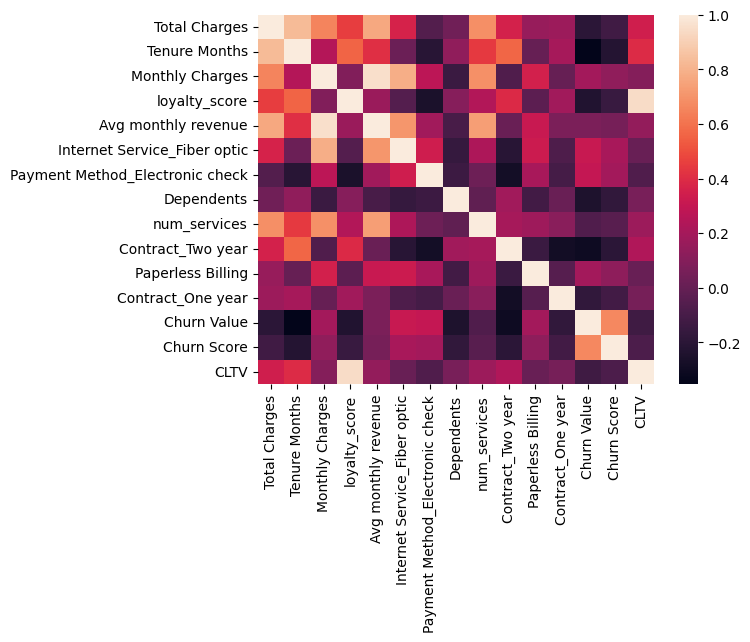

In [115]:
sns.heatmap(new_df.corr())

I identified that the engineered loyalty score was strongly correlated with CLTV and could introduce target leakage-like behavior, so it was excluded from the regression pipeline

In [116]:
x3 = new_df.drop(columns=['Churn Value', 'Churn Score', 'CLTV', 'loyalty_score'])
y3 = new_df['CLTV']

x3_train, x3_test, y3_train, y3_test = train_test_split(x3, y3, test_size=0.2, random_state=42)

for model_name, model in regression_models.items():
    model.fit(x3_train, y3_train)
    y_pred = model.predict(x3_test)
    mse = mean_squared_error(y3_test, y_pred)
    r2 = r2_score(y3_test, y_pred)
    print(f"{model_name} - MSE: {mse:.4f}, R²: {r2:.4f}")

Linear Regression - MSE: 1166737.4813, R²: 0.1600
Random Forest - MSE: 1252778.1568, R²: 0.0981
XGBoost - MSE: 1317138.3002, R²: 0.0517


After removing the engineered loyalty score to avoid leakage-like behavior, the predictive performance dropped significantly, indicating that CLTV was heavily dependent on engineered revenue-based behavioral features